## HMF-emu:

## xi-emu:

In [1]:
import h5py
import numpy as np
from matplotlib import pyplot as plt


with h5py.File('/home/qezlou/HD2/HETDEX/cosmo/data/xi_on_grid/all_compressed_10p_Box1000_Part3000_narrowz2.5.hdf5', 'r') as f:
    print(f.keys())
    mass_pairs = f['pairs'][0]
    mass_bins = np.round(np.unique(mass_pairs), 2)
    rbins = f['mbins'][:]
    corrs = f['corrs'][:]


<KeysViewHDF5 ['corrs', 'mbins', 'pairs', 'sim_id', 'sim_tags']>


In [2]:
corrs.shape, mass_bins.shape, mass_pairs.shape, rbins.shape

((15, 231, 50), (21,), (231, 2), (50,))

In [3]:

def make_3d_corr(corr, symmetric=True, mass_bins=mass_bins, mass_pairs=mass_pairs):
    """
    Pass xi(n_mass_pairs, n_rbins) and get a
    3D array (n_mass_pairs, n_mass_pairs, n_rbins)
    """
    mass_bins = mass_bins[::-1]
    ind_m_pair = np.digitize(mass_pairs, mass_bins).astype(int)
    corr_3d = np.full((mass_bins.size, mass_bins.size, corr.shape[-1]), np.nan)
    for (i,j), val in zip(ind_m_pair, corr):
        corr_3d[i,j] = val
    if symmetric:
        for i in range(mass_bins.size):
            for j in range(mass_bins.size):
                corr_3d[j,i] = corr_3d[i,j]
    return corr_3d

In [4]:
corr_3d = make_3d_corr(corrs[0], symmetric=True)

In [55]:
ind = (rbins > 0.5) & (rbins < 70)
rbins = rbins[ind]
transformed_corr_3d = np.log10(corr_3d)[:,:,ind]
transformed_corr_3d  = (transformed_corr_3d - np.nanmin(transformed_corr_3d)) / (np.nanmax(transformed_corr_3d) - np.nanmin(transformed_corr_3d))
np.nanmin(transformed_corr_3d), np.nanmax(transformed_corr_3d)


/tmp/ipykernel_69908/3141398484.py:3: RuntimeWarning: invalid value encountered in log10
  transformed_corr_3d = np.log10(corr_3d)[:,:,ind]


(0.0, 1.0)

/tmp/ipykernel_69908/3165694964.py:52: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


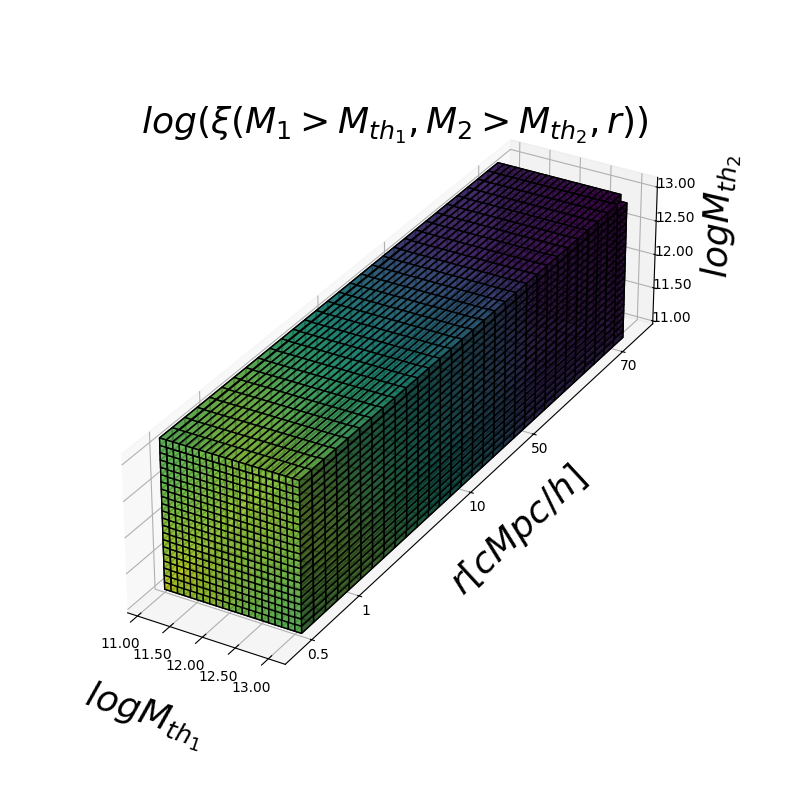

In [84]:
import numpy as np
import matplotlib.pyplot as plt

voxels_xyz = np.transpose(transformed_corr_3d, (0, 2, 1))
colors_xyz = np.transpose(transformed_corr_3d, (0, 2, 1))

Ny = voxels_xyz.shape[1]

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection='3d')

ax.voxels(
    voxels_xyz,
    facecolors=plt.cm.viridis(colors_xyz),
    edgecolor='k',
    alpha=0.8
)

ax.set_box_aspect((
    voxels_xyz.shape[0],
    3 * voxels_xyz.shape[1],  # stretch Y
    voxels_xyz.shape[2]
))




# Desired physical tick locations (in r-units)
rbins_tick_vals = np.array([0.5, 1, 10, 50, 70])

# Map physical r-values → nearest voxel indices
tick_idx = np.searchsorted(rbins, rbins_tick_vals)
tick_idx = np.clip(tick_idx, 0, Ny - 1)

ax.set_yticks(tick_idx)
ax.set_yticklabels([f"{r:g}" for r in rbins_tick_vals])

mbins_tick_vals = np.arange(mass_bins[0], mass_bins[-1] + 0.5, 0.5)
tick_idx = np.searchsorted(mass_bins, mbins_tick_vals)
tick_idx = np.clip(tick_idx, 0, mass_bins.size - 1)

ax.set_xticks(tick_idx)
ax.set_xticklabels([f"{m:.2f}" for m in mbins_tick_vals])
ax.set_zticks(tick_idx)
ax.set_zticklabels([f"{m:.2f}" for m in mbins_tick_vals])

fontsize = 26
ax.set_xlabel(r"$log M_{th_1}$", fontsize=fontsize, labelpad=20)
ax.set_ylabel(r"$r[cMpc/h]$", labelpad=50, fontsize=fontsize)
ax.set_zlabel(r"$log M_{th_2}$", labelpad=20, fontsize=fontsize)
ax.set_title(r"$log(\xi(M_1> M_{th_1}, M_2 > M_{th_2}, r))$", y=0.9, fontsize=fontsize)
fig.tight_layout()
plt.show()



In [58]:
rbins

array([ 0.50056595,  0.62000047,  0.76793194,  0.9511597 ,  1.17810543,
        1.45920017,  1.80736382,  2.27499553,  2.90060912,  3.69826365,
        4.71526961,  6.01194766,  7.66520638,  9.77310384, 12.46066368,
       15.88729045, 20.25622426, 25.82659532, 32.9287935 , 41.98406441,
       53.52949432, 60.52631579, 61.57894737, 62.63157895, 63.68421053,
       64.73684211, 65.78947368, 66.84210526, 67.89473684, 68.94736842])

In [5]:
## 2. Set the true p_grid
import numpy as np
import os
from multiprocessing import Pool
from gal_goku import gal
from gal_goku import emu_cosmo
from scipy.interpolate import make_interp_spline

hmf_model_file = '/home/qezlou/HD2/HETDEX/cosmo/data/HMF/train_pca_l14_full_comp_kernel/hmf_emu_combined_z2.5_inducing_500_latents_14_leave0_12000.pkl'
hmf_composite_kernel = ['matern32', 'matern52', 'matern32', 'matern52']
logging_level='ERROR'

hmf_model_file = f'/home/qezlou/HD2/HETDEX/cosmo/data/HMF/train_pca_l14_full_comp_kernel/hmf_emu_combined_z2.5_inducing_500_latents_14_leave3_12000.pkl'
g = gal.Gal(hmf_model_file, hmf_composite_kernel=hmf_composite_kernel, logging_level=logging_level)
g.reset_hod()

2025-12-17 06:58:46.135280: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-12-17 06:58:46.138491: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-12-17 06:58:46.147954: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765976326.163305   89559 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765976326.167898   89559 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1765976326.180420   89559 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

🔹 Initializing W with structured diagonal correlations
🔹 Using Heteroscedastic Gaussian likelihood
🔹 Initializing W with structured diagonal correlations
🔹 Using Heteroscedastic Gaussian likelihood


In [12]:
import h5py

with h5py.File('/home/qezlou/HD2/HETDEX/cosmo/data/HMF/HF_hmfs_2.5_narrow_no_merge.hdf5', 'r') as f:
    print(f.keys())
    bins = f['bins_coarse'][0]
    mbins = (bins[:-1] + bins[1:]) / 2
    hmf = f['hmfs_coarse'][0]
    print(mbins.shape, hmf.shape)

<KeysViewHDF5 ['bad_sims', 'bins_coarse', 'hmfs_coarse', 'sim_tags']>
(24,) (24,)


In [41]:
g.hmf = hmf
g.rbins = rbins
g.log_dndlog_m_spl = make_interp_spline(np.log10(mbins), g.hmf)
g.xi_grid = corr_3d.squeeze()[:,:,:]
g.k, g.p_grid = g.xi_grid_to_p_grid()
print(g.p_grid.shape)
g.p_hh_mth_bspline = None
r, xi_grid = g.get_xi_gg()

(14, 14, 300)


/home/qezlou/HD2/HETDEX/cosmo/pack_dev/private-gal-emu/src/gal_goku/gal_goku/gal.py:589: RuntimeWarning: invalid value encountered in divide
  p_exact_mass = numer / denom


AssertionError: None, p_hh_m1m2 returned NaN for masses 11.15 and 11.15

In [14]:
g.xi_grid.shape, g.rbins.shape

((21, 21, 18), (20,))

In [9]:
g.rbins, rbins

(array([ 0.50056595,  0.62000047,  0.76793194,  0.9511597 ,  1.17810543,
         1.45920017,  1.80736382,  2.27499553,  2.90060912,  3.69826365,
         4.71526961,  6.01194766,  7.66520638,  9.77310384, 12.46066368,
        15.88729045, 20.25622426, 25.82659532, 32.9287935 , 41.98406441]),
 array([1.57721735e-02, 3.39801176e-02, 7.32079442e-02, 1.11929948e-01,
        1.38636319e-01, 1.71714801e-01, 2.12685776e-01, 2.63432382e-01,
        3.26287077e-01, 4.04138837e-01, 5.00565947e-01, 6.20000465e-01,
        7.67931937e-01, 9.51159705e-01, 1.17810543e+00, 1.45920017e+00,
        1.80736382e+00, 2.27499553e+00, 2.90060912e+00, 3.69826365e+00,
        4.71526961e+00, 6.01194766e+00, 7.66520638e+00, 9.77310384e+00,
        1.24606637e+01, 1.58872905e+01, 2.02562243e+01, 2.58265953e+01,
        3.29287935e+01, 4.19840644e+01, 5.35294943e+01, 6.05263158e+01,
        6.15789474e+01, 6.26315789e+01, 6.36842105e+01, 6.47368421e+01,
        6.57894737e+01, 6.68421053e+01, 6.78947368e+01, 6.

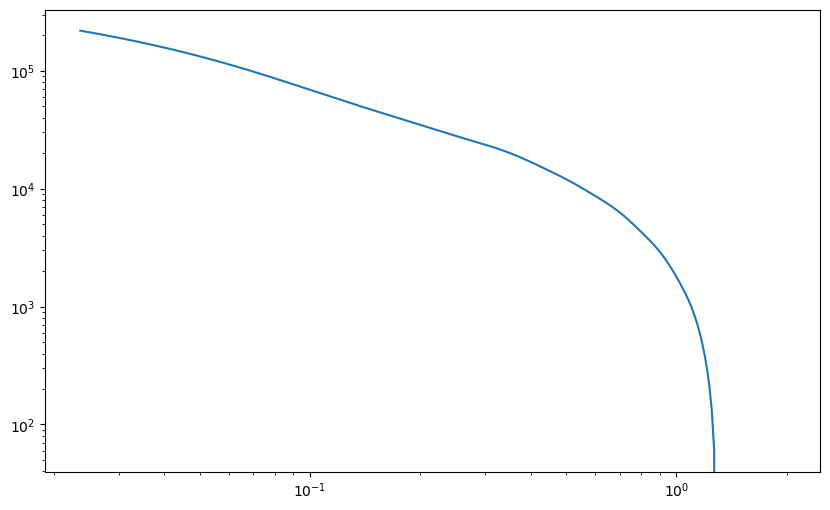

In [21]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(g.k, g.p_grid[0, 0, :], label='p_grid')
ax.set_xscale('log')
ax.set_yscale('log')

In [35]:
transformed_corr_3d = np.log10(g.p_grid[:,:,:])
transformed_corr_3d  = (transformed_corr_3d - np.nanmin(transformed_corr_3d)) / (np.nanmax(transformed_corr_3d) - np.nanmin(transformed_corr_3d))

/tmp/ipykernel_89559/2035918794.py:1: RuntimeWarning: invalid value encountered in log10
  transformed_corr_3d = np.log10(g.p_grid[:,:,:])


In [36]:
g.k

array([0.02359533, 0.02394747, 0.02430486, 0.02466759, 0.02503573,
       0.02540936, 0.02578857, 0.02617344, 0.02656405, 0.02696049,
       0.02736285, 0.02777121, 0.02818567, 0.02860631, 0.02903323,
       0.02946653, 0.02990628, 0.03035261, 0.03080559, 0.03126533,
       0.03173193, 0.0322055 , 0.03268614, 0.03317395, 0.03366903,
       0.03417151, 0.03468149, 0.03519907, 0.03572438, 0.03625753,
       0.03679864, 0.03734782, 0.0379052 , 0.0384709 , 0.03904504,
       0.03962775, 0.04021915, 0.04081938, 0.04142857, 0.04204685,
       0.04267436, 0.04331123, 0.04395761, 0.04461363, 0.04527944,
       0.04595519, 0.04664103, 0.0473371 , 0.04804356, 0.04876056,
       0.04948826, 0.05022683, 0.05097641, 0.05173718, 0.05250931,
       0.05329296, 0.0540883 , 0.05489552, 0.05571478, 0.05654626,
       0.05739016, 0.05824665, 0.05911593, 0.05999817, 0.06089358,
       0.06180236, 0.0627247 , 0.0636608 , 0.06461088, 0.06557513,
       0.06655377, 0.06754702, 0.06855509, 0.06957821, 0.07061

/tmp/ipykernel_89559/3212092588.py:51: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


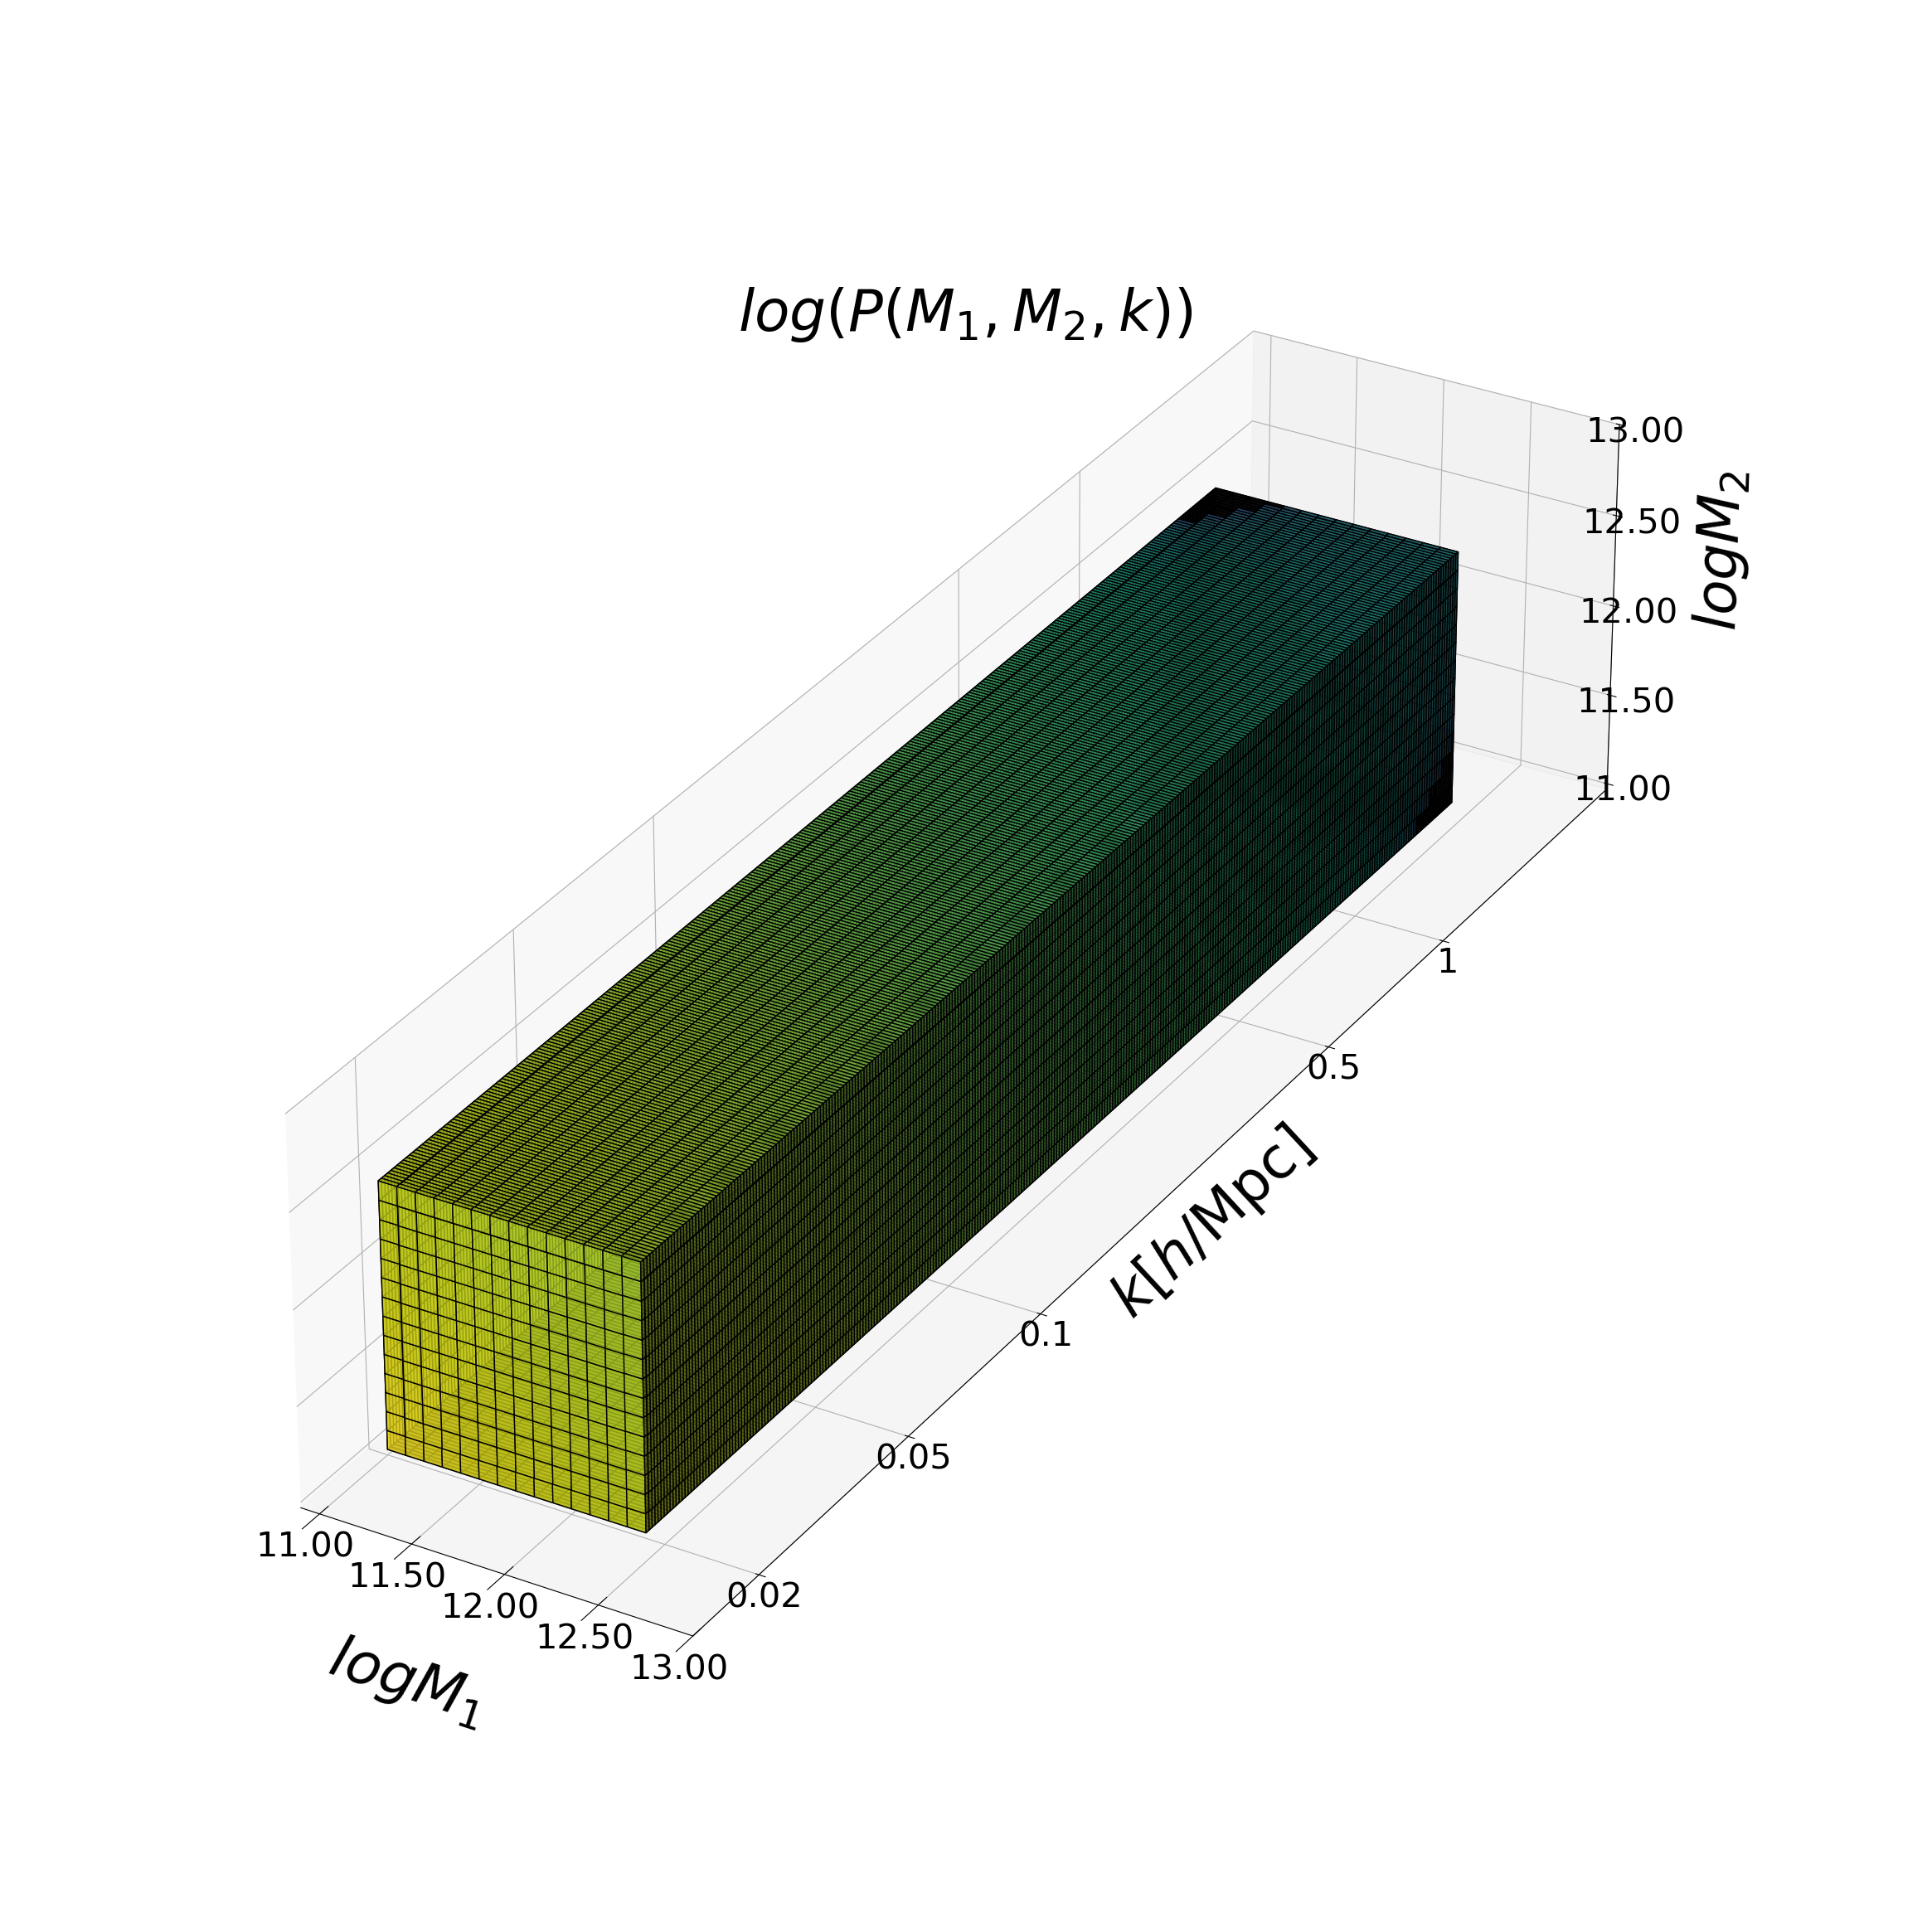

In [46]:
import numpy as np
import matplotlib.pyplot as plt

voxels_xyz = np.transpose(transformed_corr_3d, (0, 2, 1))
colors_xyz = np.transpose(transformed_corr_3d, (0, 2, 1))

Ny = voxels_xyz.shape[1]

fig = plt.figure(figsize=(30, 30))
ax = fig.add_subplot(projection='3d')

ax.voxels(
    voxels_xyz,
    facecolors=plt.cm.viridis(colors_xyz),
    edgecolor='k',
    alpha=0.8
)

ax.set_box_aspect((
    5*voxels_xyz.shape[0],
     voxels_xyz.shape[1],  # stretch Y
    5*voxels_xyz.shape[2]
))




# Desired physical tick locations (in r-units)
kbins_tick_vals = np.array([0.02, 0.05, 0.1, 0.5, 1])

# Map physical r-values → nearest voxel indices
tick_idx = np.searchsorted(g.k,kbins_tick_vals)
tick_idx = np.clip(tick_idx, 0, Ny - 1)

ax.set_yticks(tick_idx)
ax.set_yticklabels([f"{k:g}" for k in kbins_tick_vals], fontsize=30)
mbins_tick_vals = np.arange(mass_bins[0], mass_bins[-1] + 0.5, 0.5)
tick_idx = np.searchsorted(mass_bins, mbins_tick_vals)
tick_idx = np.clip(tick_idx, 0, mass_bins.size - 1)

ax.set_xticks(tick_idx)
ax.set_xticklabels([f"{m:.2f}" for m in mbins_tick_vals], fontsize=30)
ax.set_zticks(tick_idx)
ax.set_zticklabels([f"{m:.2f}" for m in mbins_tick_vals], fontsize=30)

fontsize = 50
ax.set_xlabel(r"$log M_{1}$", fontsize=fontsize, labelpad=50)
ax.set_ylabel(r"$k[h/\mathrm{Mpc}]$", labelpad=50, fontsize=fontsize)
ax.set_zlabel(r"$log M_{2}$", labelpad=60, fontsize=fontsize)
ax.set_title(r"$log(P(M_1, M_2, k))$", y=0.9, fontsize=fontsize)
fig.tight_layout()
plt.show()




